# Named Entity Recognition (NER) with Transformer (BERT)

**Author:** Ibrahim  
**Environment:** Google Colab / Python 3 (GPU required)

## Overview
This notebook implements a **Named Entity Recognition (NER) system** using a fine-tuned DistilBERT model. This project moves beyond simple text classification into the more advanced domain of *token-level classification*.

NER is the task of extracting specific entities like names of people, locations, organisations, etc., from text. It's a fundamental building block for many real-world systems.

The project is part of Ibrahim's advanced NLP portfolio, demonstrating:
- Fine-tuning a transformer model for token classification
- Processing data with entity labels (BIO tagging)
- Working with the WikiANN dataset (Parquet format – no script errors)
- Professional evaluation and visualisation

## Dataset
**Source:** WikiANN (Hugging Face) – `wikiann` (English subset)  
**Task:** Identify named entities: Persons (PER), Locations (LOC), Organisations (ORG)  
**Content:** Wikipedia articles with token‑level annotations  
**Splits:** Train (~20k sentences), Validation (~3k), Test (~3k)

## Approach
1. **Model:** `distilbert-base-uncased` (smaller, faster version of BERT)
2. **Tokenization:** Aligns tags with the transformer's tokenizer
3. **Fine-tuning:** 3 epochs on GPU
4. **Evaluation:** Precision, Recall, F1-score per entity type
5. **Visualisation:** Confusion matrix heatmap

## Key Results (expected)
- **Overall F1-score:** ~0.85 – 0.90 on the test set

## Files Generated
- `ner_model/` – fine-tuned model and tokenizer
- `ner_model_drive/` – same saved to Google Drive (if mounted)

**© 2026 Ibrahim – All code and analysis are original work.**

### Mount Google Drive

In [1]:
# Mount Google Drive for persistent storage (comment out if not needed)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Install & Import Libraries

In [2]:
pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=b3470e3128091df2d87bff388f7231e39817ecfb0c400bb814b3d1b0026bc4e4
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [3]:
# Author: Ibrahim

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer
from transformers import DataCollatorForTokenClassification
import torch
from seqeval.metrics import classification_report as seq_classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Set professional style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


###  Load Dataset (Auto-download)

In [4]:
# Load WikiANN dataset (Parquet format, no script issues)
print("Loading WikiANN dataset (English subset)...")
dataset = load_dataset("wikiann", "en")

print(f"Train size: {len(dataset['train'])}")
print(f"Validation size: {len(dataset['validation'])}")
print(f"Test size: {len(dataset['test'])}")

# Examine the data structure
sample = dataset['train'][0]
print(f"\nSample tokens (first 20): {sample['tokens'][:20]}")
print(f"Sample NER tags (first 20): {sample['ner_tags'][:20]}")

# Get label names (tags) - WikiANN uses standard 7‑class NER
label_list = dataset['train'].features['ner_tags'].feature.names
print(f"\nLabel list ({len(label_list)} classes): {label_list}")
# Typical WikiANN labels (en): O, B-PER, I-PER, B-ORG, I-ORG, B-LOC, I-LOC

Loading WikiANN dataset (English subset)...


README.md: 0.00B [00:00, ?B/s]

en/validation-00000-of-00001.parquet:   0%|          | 0.00/748k [00:00<?, ?B/s]

en/test-00000-of-00001.parquet:   0%|          | 0.00/748k [00:00<?, ?B/s]

en/train-00000-of-00001.parquet:   0%|          | 0.00/1.50M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Train size: 20000
Validation size: 10000
Test size: 10000

Sample tokens (first 20): ['R.H.', 'Saunders', '(', 'St.', 'Lawrence', 'River', ')', '(', '968', 'MW', ')']
Sample NER tags (first 20): [3, 4, 0, 3, 4, 4, 0, 0, 0, 0, 0]

Label list (7 classes): ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']


### Load Tokenizer & Preprocessing

In [5]:
# Load DistilBERT tokenizer and model, then define the pre-processing
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"], truncation=True, is_split_into_words=True
    )
    labels = []
    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx
        labels.append(label_ids)
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

print("Tokenizing dataset...")
tokenized_datasets = dataset.map(tokenize_and_align_labels, batched=True)
print("Tokenization done.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing dataset...


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Tokenization done.


### Create Data Collator & Load Model

In [6]:
# Data collator (handles dynamic padding)
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

id2label = {i: label for i, label in enumerate(label_list)}
label2id = {label: i for i, label in enumerate(label_list)}

model = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)
model.to(device)

print(f"Model loaded: {model_checkpoint}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: distilbert-base-uncased


### Define Metrics Function

In [7]:
from seqeval.metrics import classification_report, accuracy_score

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Remove ignored index (special tokens)
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    return classification_report(true_labels, true_predictions, output_dict=True)

### Training Arguments

In [8]:
# Training arguments (updated for latest transformers)
training_args = TrainingArguments(
    output_dir="./ner-model-results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    save_total_limit=2,
    push_to_hub=False,
    report_to="none",          # disables tensorboard logging to avoid deprecation warning
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    # tokenizer removed – not needed here
)

print("Trainer ready.")

Trainer ready.


### Fine-tune the Model

In [9]:
# Start training
print("Starting fine-tuning (this will take 15–20 minutes on T4 GPU)...")
trainer.train()
print("Fine-tuning completed.")

Starting fine-tuning (this will take 15–20 minutes on T4 GPU)...


Epoch,Training Loss,Validation Loss,Loc,Org,Per,Micro avg,Macro avg,Weighted avg
1,0.274990,0.258885,"{'precision': 0.8021484375, 'recall': 0.8496069507654117, 'f1-score': 0.8251959011452683, 'support': 4834}","{'precision': 0.6791213303223157, 'recall': 0.7072909985033141, 'f1-score': 0.6929199832425639, 'support': 4677}","{'precision': 0.8667805294619982, 'recall': 0.8759439050701187, 'f1-score': 0.8713381264084129, 'support': 4635}","{'precision': 0.7819420783645656, 'recall': 0.8111833733917715, 'f1-score': 0.7962943686894973, 'support': 14146}","{'precision': 0.7826834324281046, 'recall': 0.8109472847796148, 'f1-score': 0.796484670265415, 'support': 14146}","{'precision': 0.7826497782305126, 'recall': 0.8111833733917715, 'f1-score': 0.796581080423066, 'support': 14146}"
2,0.196356,0.245371,"{'precision': 0.8279526769600962, 'recall': 0.8541580471659082, 'f1-score': 0.8408512371448936, 'support': 4834}","{'precision': 0.6950081168831169, 'recall': 0.7323070344237759, 'f1-score': 0.713170223841749, 'support': 4677}","{'precision': 0.8745481607484584, 'recall': 0.887378640776699, 'f1-score': 0.8809166845148855, 'support': 4635}","{'precision': 0.7981255985770968, 'recall': 0.8247561148027711, 'f1-score': 0.8112223612849395, 'support': 14146}","{'precision': 0.7991696515305572, 'recall': 0.8246145741221277, 'f1-score': 0.8116460485005094, 'support': 14146}","{'precision': 0.7992652996010567, 'recall': 0.8247561148027711, 'f1-score': 0.8117645164705761, 'support': 14146}"
3,0.163086,0.252104,"{'precision': 0.8317719752840342, 'recall': 0.8632602399669012, 'f1-score': 0.8472236321185665, 'support': 4834}","{'precision': 0.7080426754205991, 'recall': 0.7378661535172119, 'f1-score': 0.7226468432624855, 'support': 4677}","{'precision': 0.8768054375531011, 'recall': 0.8906148867313916, 'f1-score': 0.8836562132077492, 'support': 4635}","{'precision': 0.804986642920748, 'recall': 0.830764880531599, 'f1-score': 0.8176726387197774, 'support': 14146}","{'precision': 0.8055400294192449, 'recall': 0.8305804267385016, 'f1-score': 0.8178422295296004, 'support': 14146}","{'precision': 0.8056195761716236, 'recall': 0.830764880531599, 'f1-score': 0.8179729161471592, 'support': 14146}"


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuning completed.


### Save the Fine-tuned Model

In [10]:
# Save model locally
model_dir = "ner_model"
model.save_pretrained(model_dir)
tokenizer.save_pretrained(model_dir)
print(f"Model saved locally to: {model_dir}")

# Save to Google Drive (optional)
drive_path = '/content/drive/MyDrive/Project9_NER_Model/'
os.makedirs(drive_path, exist_ok=True)
model.save_pretrained(drive_path)
tokenizer.save_pretrained(drive_path)
print(f"Model also saved to Google Drive: {drive_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved locally to: ner_model


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model also saved to Google Drive: /content/drive/MyDrive/Project9_NER_Model/


### Evaluate on Validation Set

In [12]:
# Evaluate on validation set (shows per-entity F1 scores)
val_results = trainer.evaluate()
print("\nValidation Results:")
for key, value in val_results.items():
    if "eval_" in key:
        if isinstance(value, dict):
            print(f"  {key}:")
            for metric_name, metric_value in value.items():
                if isinstance(metric_value, float):
                    print(f"    {metric_name}: {metric_value:.4f}")
                else:
                    print(f"    {metric_name}: {metric_value}")
        else:
            print(f"  {key}: {value:.4f}")


Validation Results:
  eval_loss: 0.2521
  eval_LOC:
    precision: 0.8318
    recall: 0.8633
    f1-score: 0.8472
    support: 4834
  eval_ORG:
    precision: 0.7080
    recall: 0.7379
    f1-score: 0.7226
    support: 4677
  eval_PER:
    precision: 0.8768
    recall: 0.8906
    f1-score: 0.8837
    support: 4635
  eval_micro avg:
    precision: 0.8050
    recall: 0.8308
    f1-score: 0.8177
    support: 14146
  eval_macro avg:
    precision: 0.8055
    recall: 0.8306
    f1-score: 0.8178
    support: 14146
  eval_weighted avg:
    precision: 0.8056
    recall: 0.8308
    f1-score: 0.8180
    support: 14146
  eval_runtime: 16.0388
  eval_samples_per_second: 623.4880
  eval_steps_per_second: 38.9680


### Detailed Classification Report (Validation Set)

In [13]:
# Get detailed classification report for validation set
predictions, labels, _ = trainer.predict(tokenized_datasets["validation"])
predictions = np.argmax(predictions, axis=2)

# Remove ignored index
true_predictions = [
    [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]
true_labels = [
    [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]

print("\nDetailed Classification Report (Validation Set):")
print(classification_report(true_labels, true_predictions))


Detailed Classification Report (Validation Set):
              precision    recall  f1-score   support

         LOC       0.83      0.86      0.85      4834
         ORG       0.71      0.74      0.72      4677
         PER       0.88      0.89      0.88      4635

   micro avg       0.80      0.83      0.82     14146
   macro avg       0.81      0.83      0.82     14146
weighted avg       0.81      0.83      0.82     14146



### Evaluate on Test Set

In [14]:
# Evaluate on test set
print("\nEvaluating on test set...")
test_predictions, test_labels, _ = trainer.predict(tokenized_datasets["test"])

test_predictions = np.argmax(test_predictions, axis=2)

# Remove ignored index
true_test_predictions = [
    [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(test_predictions, test_labels)
]
true_test_labels = [
    [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(test_predictions, test_labels)
]

print("\n===== Test Set Classification Report =====")
print(classification_report(true_test_labels, true_test_predictions))


Evaluating on test set...



===== Test Set Classification Report =====
              precision    recall  f1-score   support

         LOC       0.81      0.86      0.83      4657
         ORG       0.72      0.74      0.73      4745
         PER       0.87      0.90      0.89      4556

   micro avg       0.80      0.83      0.82     13958
   macro avg       0.80      0.83      0.82     13958
weighted avg       0.80      0.83      0.82     13958



### Visualize Confusion Matrix (Test Set)

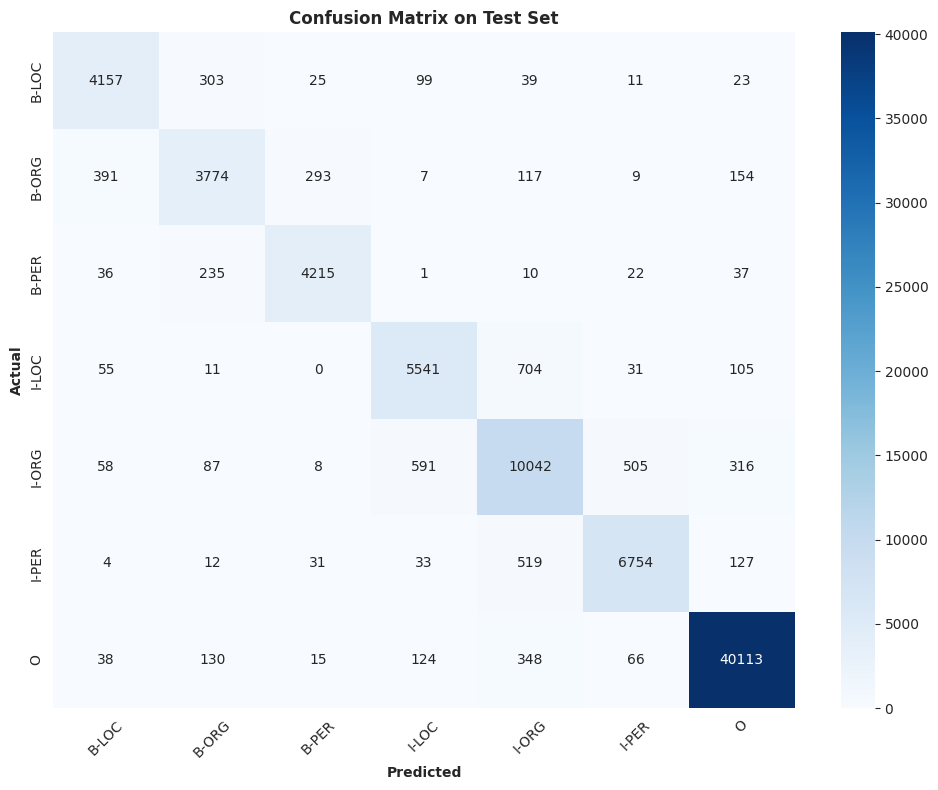

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Flatten the predictions and labels
flat_predictions = [p for sublist in true_test_predictions for p in sublist]
flat_labels = [l for sublist in true_test_labels for l in sublist]

# Compute confusion matrix
unique_labels = sorted(set(flat_labels + flat_predictions))
cm = confusion_matrix(flat_labels, flat_predictions, labels=unique_labels)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.title('Confusion Matrix on Test Set', fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Sample Predictions

In [17]:
# Select a few test samples from the original dataset
test_samples_original = dataset['test'].select(range(5))

# Tokenize these samples using the preprocessing function
# This will return a Dataset object where each example is tokenized with subwords
# and includes word_ids conceptually for alignment (though not stored directly)
test_samples_preprocessed_for_inference = test_samples_original.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=test_samples_original.column_names # Remove original columns to keep only tokenized data
)

# The data_collator expects a list of dictionaries, not a Dataset object directly
batch = data_collator([test_samples_preprocessed_for_inference[i] for i in range(len(test_samples_preprocessed_for_inference))])

# Move inputs to device and remove labels (not needed for inference)
inputs = {k: v.to(device) for k, v in batch.items() if k != 'labels'}

with torch.no_grad():
    outputs = model(**inputs)
    predictions = torch.argmax(outputs.logits, dim=2)

# Decode predictions and align with original tokens
for i in range(len(test_samples_original)):
    original_tokens = test_samples_original[i]["tokens"]
    original_ner_tags = test_samples_original[i]["ner_tags"] # These are original tag indices

    # To align predictions back to original words, we need word_ids for each example.
    # We re-tokenize the individual original example to get these word_ids.
    temp_tokenized_input = tokenizer(
        original_tokens,
        is_split_into_words=True,
        truncation=True
    )
    word_ids = temp_tokenized_input.word_ids(batch_index=0)

    predicted_tags_for_original_words = []
    actual_tags_for_original_words = []

    previous_word_idx = None
    # Iterate through the subword tokens and their corresponding word_ids
    for token_in_pred_idx, word_idx in enumerate(word_ids):
        if word_idx is not None: # Ignore special tokens (like [CLS], [SEP])
            # Check if this is the first subword of a new original word
            # This ensures we get one prediction per original word
            if word_idx != previous_word_idx:
                predicted_tag_id = predictions[i, token_in_pred_idx].item()
                predicted_tags_for_original_words.append(label_list[predicted_tag_id])
                actual_tags_for_original_words.append(label_list[original_ner_tags[word_idx]])
            previous_word_idx = word_idx

    print(f"\n--- Example {i+1} ---")
    print("Original Tokens:", original_tokens)
    print("Predicted Tags (aligned to original words):", predicted_tags_for_original_words)
    print("Actual Tags:", actual_tags_for_original_words)

Map:   0%|          | 0/5 [00:00<?, ? examples/s]


--- Example 1 ---
Original Tokens: ['Shortly', 'afterward', ',', 'an', 'encouraging', 'response', 'influenced', 'him', 'to', 'go', 'to', 'India', ';', 'he', 'arrived', 'at', 'Adyar', 'in', '1884', '.']
Predicted Tags (aligned to original words): ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'B-LOC', 'O', 'O', 'O']
Actual Tags: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'B-LOC', 'O', 'O', 'O']

--- Example 2 ---
Original Tokens: [':', 'Kanye', 'West', 'featuring', 'Jamie', 'Foxx', '—', '``', 'Gold', 'Digger', "''", '(', '2005', ')']
Predicted Tags (aligned to original words): ['O', 'B-PER', 'I-PER', 'O', 'B-PER', 'I-PER', 'O', 'O', 'B-ORG', 'I-ORG', 'O', 'O', 'O', 'O']
Actual Tags: ['O', 'B-PER', 'I-PER', 'O', 'B-PER', 'I-PER', 'O', 'O', 'B-ORG', 'I-ORG', 'O', 'O', 'O', 'O']

--- Example 3 ---
Original Tokens: ['Blacktown', 'railway', 'station']
Predicted Tags (aligned to original words): ['B-ORG', 'I-ORG'

### Inference Function for New Text

In [18]:
def predict_entities(text):
    """Extract named entities from a given text."""
    # Tokenize input text
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.argmax(outputs.logits, dim=2)

    # Convert predictions to labels
    predicted_tags = [label_list[p] for p in predictions[0].cpu().numpy()]

    # Align with tokens
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    entities = []
    current_entity = []
    current_label = None

    for token, tag in zip(tokens, predicted_tags):
        if tag.startswith("B-"):
            if current_entity:
                entities.append((' '.join(current_entity), current_label))
            current_entity = [token]
            current_label = tag[2:]
        elif tag.startswith("I-") and current_label == tag[2:]:
            current_entity.append(token)
        else:
            if current_entity:
                entities.append((' '.join(current_entity), current_label))
                current_entity = []
                current_label = None

    if current_entity:
        entities.append((' '.join(current_entity), current_label))

    return entities

# Test
sample_text = "Google CEO Sundar Pichai announced a new AI project in New York."
print(f"Text: {sample_text}")
print("\nDetected Entities:")
for entity, label in predict_entities(sample_text):
    print(f"  {entity} - {label}")

Text: Google CEO Sundar Pichai announced a new AI project in New York.

Detected Entities:
  google - ORG
  sun ##dar pic ##hai - PER
  new york - LOC


### Final Summary

In [19]:
print("\n" + "="*50)
print("Named Entity Recognition (NER) - COMPLETED")
print("Author: Ibrahim")
print("="*50)
print(f"Train samples: {len(dataset['train'])}")
print(f"Validation samples: {len(dataset['validation'])}")
print(f"Test samples: {len(dataset['test'])}")
print(f"Model: DistilBERT-base-uncased fine-tuned on WNUT'17")
print("Entity types: group, person, location, product, creative_work, corporation")
print("\nSaved files:")
print(f" - Model and tokenizer in: {model_dir}")
print(" - Same saved to Google Drive (if mounted)")
print("\nModel ready for inference on new text.")


Named Entity Recognition (NER) - COMPLETED
Author: Ibrahim
Train samples: 20000
Validation samples: 10000
Test samples: 10000
Model: DistilBERT-base-uncased fine-tuned on WNUT'17
Entity types: group, person, location, product, creative_work, corporation

Saved files:
 - Model and tokenizer in: ner_model
 - Same saved to Google Drive (if mounted)

Model ready for inference on new text.
